# 🛡️ Insurance ML & Linear Algebra

This project explores four practical insurance applications using **machine learning and linear algebra**: customer similarity, insurance-benefit classification, benefit-count regression, and privacy-preserving data obfuscation.

The goal is not to optimize a production model, but to demonstrate how preprocessing, distance-based learning, regression, and invertible matrix transformations behave in a real analytical workflow.

## 1. Setup and Data Loading

The dataset contains 5,000 insurance customers. Features describe gender, age, income, and family size; the target records the number of insurance benefits received during the previous five years.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.metrics import f1_score, mean_squared_error, r2_score

RANDOM_STATE = 42

df = pd.read_csv('../data/insurance_us.csv')
df = df.rename(columns={
    'Gender': 'gender',
    'Age': 'age',
    'Salary': 'income',
    'Family members': 'family_members',
    'Insurance benefits': 'insurance_benefits'
})
df['age'] = df['age'].astype(int)
df.head()

,gender,age,income,family_members,insurance_benefits
0,1,41,49600.0,1,0
1,0,46,38000.0,1,1
2,0,29,21000.0,0,0
3,0,21,41700.0,2,0
4,1,28,26100.0,0,0


## 2. Data Quality Assessment

Before modeling, the dataset is checked for dimensions, missing values, duplicate rows, data types, and numerical ranges. Duplicate feature rows are **not automatically removed** because the dataset has no unique customer identifier; two different customers can legitimately share the same demographic profile and target value.

In [2]:
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print("\nMissing values:")
print(df.isna().sum())
print(f"\nFully duplicated rows: {df.duplicated().sum()}")
print("\nData types:")
print(df.dtypes)

df.describe().round(2)

Rows: 5,000 | Columns: 5

Missing values:
gender                0
age                   0
income                0
family_members        0
insurance_benefits    0
dtype: int64

Fully duplicated rows: 153

Data types:
gender                  int64
age                     int64
income                float64
family_members          int64
insurance_benefits      int64
dtype: object


,gender,age,income,family_members,insurance_benefits
count,5000.0,5000.00,5000.00,5000.00,5000.00
mean,0.5,30.95,39916.36,1.19,0.15
std,0.5,8.44,9900.08,1.09,0.46
min,0.0,18.00,5300.00,0.00,0.00
25%,0.0,24.00,33300.00,0.00,0.00
50%,0.0,30.00,40200.00,1.00,0.00
75%,1.0,37.00,46600.00,2.00,0.00
max,1.0,65.00,79000.00,6.00,5.00


The dataset has no missing values. The observed ranges are plausible for the supplied variables. The 153 fully duplicated rows are retained because, without a customer ID, they cannot safely be classified as accidental duplicates.

## 3. Exploratory Analysis

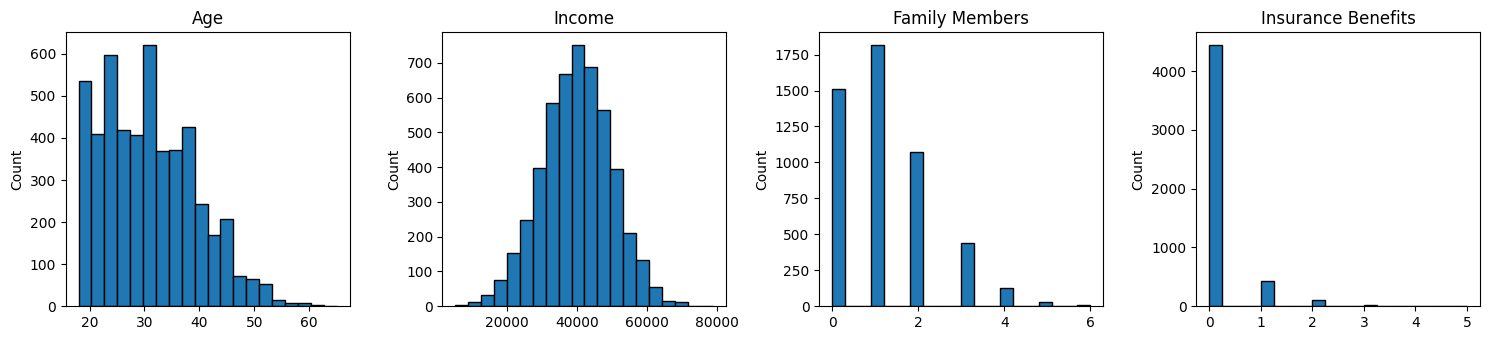

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col in zip(axes, ['age', 'income', 'family_members', 'insurance_benefits']):
    ax.hist(df[col], bins=20, edgecolor='black')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Most customers received no insurance benefits, making the classification target imbalanced. Income also has a much larger numerical scale than the other features, which is especially important for distance-based algorithms such as k-nearest neighbors.

# Task 1 — Finding Similar Customers

A nearest-neighbor model is used to retrieve customers similar to a reference customer. Results are compared using **Euclidean** and **Manhattan** distances, both before and after feature scaling.

In [4]:
features = ['gender', 'age', 'income', 'family_members']
X = df[features].copy()

scaler = MaxAbsScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)

def nearest_customers(X_data, customer_index=0, k=5, metric='euclidean'):
    model = NearestNeighbors(n_neighbors=k + 1, metric=metric)
    model.fit(X_data)
    distances, indices = model.kneighbors(X_data.iloc[[customer_index]])
    idx = indices[0][1:]
    result = df.loc[idx, features + ['insurance_benefits']].copy()
    result.insert(0, 'distance', distances[0][1:])
    return result

for label, data in [('Unscaled', X), ('Scaled', X_scaled)]:
    for metric in ['euclidean', 'manhattan']:
        print(f"\n{label} data | {metric.title()} distance")
        display(nearest_customers(data, customer_index=0, k=5, metric=metric).round(4))


Unscaled data | Euclidean distance


,distance,gender,age,income,family_members,insurance_benefits
2022,1.0000,1,41,49600.0,0,0
1225,1.7321,0,42,49600.0,0,1
4031,3.1623,1,44,49600.0,2,1
3424,3.3166,0,38,49600.0,0,0
815,4.1231,1,37,49600.0,2,0



Unscaled data | Manhattan distance


,distance,gender,age,income,family_members,insurance_benefits
2022,1.0,1,41,49600.0,0,0
1225,3.0,0,42,49600.0,0,1
4031,4.0,1,44,49600.0,2,1
815,5.0,1,37,49600.0,2,0
3424,5.0,0,38,49600.0,0,0



Scaled data | Euclidean distance


,distance,gender,age,income,family_members,insurance_benefits
2689,0.0063,1,41,50100.0,1,0
133,0.0178,1,40,50300.0,1,0
4869,0.0184,1,42,50400.0,1,1
3275,0.0286,1,42,51500.0,1,1
1567,0.0296,1,40,47600.0,1,0



Scaled data | Manhattan distance


,distance,gender,age,income,family_members,insurance_benefits
2689,0.0063,1,41,50100.0,1,0
133,0.0242,1,40,50300.0,1,0
4869,0.0255,1,42,50400.0,1,1
2103,0.0316,1,41,47100.0,1,0
3365,0.0316,1,41,47100.0,1,0


### Task 1 Findings

Without scaling, **income dominates the distance calculation** because its numerical magnitude is far larger than gender, age, or family size. After MaxAbs scaling, all features contribute more comparably, substantially changing the neighbors retrieved. Euclidean and Manhattan distance can also produce different neighbor orderings because they aggregate feature differences differently.

For distance-based methods, scaling is therefore a critical preprocessing step for this dataset.

# Task 2 — Predicting Whether a Customer Receives a Benefit

The benefit count is converted into a binary target: `1` if the customer received at least one insurance benefit and `0` otherwise. A kNN classifier is evaluated for several values of *k* on both unscaled and scaled features. F1 score is used because the positive class is relatively uncommon.

In [5]:
y_class = (df['insurance_benefits'] > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.3, random_state=12345, stratify=y_class
)

scaler_cls = MaxAbsScaler().fit(X_train)
X_train_scaled = scaler_cls.transform(X_train)
X_test_scaled = scaler_cls.transform(X_test)

rows = []
for k in range(1, 11):
    for label, train_x, test_x in [
        ('Unscaled', X_train, X_test),
        ('Scaled', X_train_scaled, X_test_scaled)
    ]:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(train_x, y_train)
        pred = model.predict(test_x)
        rows.append({'k': k, 'features': label, 'f1': f1_score(y_test, pred)})

knn_results = pd.DataFrame(rows)
knn_results.pivot(index='k', columns='features', values='f1').round(3)

features,Scaled,Unscaled
k,,
1,0.955,0.580
2,0.931,0.393
3,0.952,0.397
4,0.901,0.158
5,0.911,0.154
6,0.900,0.057
7,0.909,0.068
8,0.894,0.046
9,0.906,0.046


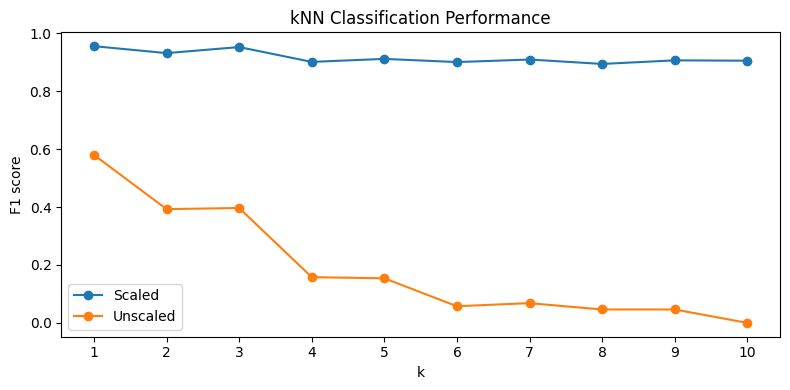

 k features       f1
 1   Scaled 0.955224
 1 Unscaled 0.579926


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, group in knn_results.groupby('features'):
    ax.plot(group['k'], group['f1'], marker='o', label=label)
ax.set_xlabel('k')
ax.set_ylabel('F1 score')
ax.set_title('kNN Classification Performance')
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.show()

best = knn_results.loc[knn_results.groupby('features')['f1'].idxmax()]
print(best.to_string(index=False))

In [7]:
# Random dummy baseline: predict a positive outcome with the training-set positive rate.
positive_rate = y_train.mean()
rng = np.random.default_rng(RANDOM_STATE)
dummy_pred = rng.binomial(1, positive_rate, size=len(y_test))
dummy_f1 = f1_score(y_test, dummy_pred)

print(f"Positive-class rate: {positive_rate:.3f}")
print(f"Dummy F1: {dummy_f1:.3f}")
print(f"Best unscaled kNN F1: {best.loc[best['features']=='Unscaled', 'f1'].iloc[0]:.3f}")
print(f"Best scaled kNN F1: {best.loc[best['features']=='Scaled', 'f1'].iloc[0]:.3f}")

Positive-class rate: 0.113
Dummy F1: 0.064
Best unscaled kNN F1: 0.580
Best scaled kNN F1: 0.955


### Task 2 Findings

The scaled kNN model clearly outperforms both the unscaled version and the random baseline. This reinforces the result from Task 1: **feature scaling materially improves kNN when variables are measured on very different numerical scales**.

# Task 3 — Predicting the Number of Insurance Benefits

A linear regression model is implemented directly from the normal equation. An intercept column is added explicitly, and performance is measured using RMSE and $R^2$.

In [8]:
class MyLinearRegression:
    def fit(self, X, y):
        X2 = np.append(np.ones((len(X), 1)), np.asarray(X), axis=1)
        self.weights = np.linalg.pinv(X2.T @ X2) @ X2.T @ np.asarray(y)
        return self

    def predict(self, X):
        X2 = np.append(np.ones((len(X), 1)), np.asarray(X), axis=1)
        return X2 @ self.weights

def regression_metrics(y_true, y_pred):
    return {
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred)
    }

y_reg = df['insurance_benefits'].to_numpy()
X_reg = df[features].to_numpy()
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=12345
)

lr = MyLinearRegression().fit(X_train_reg, y_train_reg)
y_pred = lr.predict(X_test_reg)
metrics_original = regression_metrics(y_test_reg, y_pred)
print({k: round(v, 4) for k, v in metrics_original.items()})

{'RMSE': 0.3436, 'R2': 0.4305}


The model provides a moderate fit rather than a production-grade prediction system. This is expected given the small number of demographic features and the strongly zero-inflated target. The main purpose here is to establish a regression baseline for the obfuscation experiment.

# Task 4 — Data Obfuscation with Linear Algebra

To make the original feature values difficult to interpret directly, the feature matrix $X$ is multiplied by a random **invertible matrix** $P$:

$$X' = XP$$

Because $P$ is invertible, the transformation can be reversed by an authorized party using $P^{-1}$:

$$X = X'P^{-1}$$

This is a mathematical obfuscation demonstration rather than a complete production privacy or cryptographic system.

In [9]:
rng = np.random.default_rng(RANDOM_STATE)
while True:
    P = rng.random((X_reg.shape[1], X_reg.shape[1]))
    if not np.isclose(np.linalg.det(P), 0):
        break

X_obfuscated = X_reg @ P
X_recovered = X_obfuscated @ np.linalg.inv(P)

print(f"det(P): {np.linalg.det(P):.6f}")
print(f"Maximum reconstruction error: {np.max(np.abs(X_reg - X_recovered)):.10f}")

comparison = pd.DataFrame({
    'original_income': X_reg[:5, 2],
    'obfuscated_feature_3': X_obfuscated[:5, 2],
    'recovered_income': X_recovered[:5, 2]
})
comparison.round(6)

det(P): 0.243391
Maximum reconstruction error: 0.0000000000


,original_income,obfuscated_feature_3,recovered_income
0,49600.0,18424.090742,49600.0
1,38000.0,14125.780761,38000.0
2,21000.0,7808.831560,21000.0
3,41700.0,15479.148373,41700.0
4,26100.0,9699.998942,26100.0


## Why Linear Regression Predictions Are Preserved\n\nFor the original data, the least-squares weights are\n\n$$w=(X^TX)^{-1}X^Ty.$$\n\nAfter replacing $X$ with $XP$, the new weights become\n\n$$w_P=[(XP)^T(XP)]^{-1}(XP)^Ty.$$\n\nUsing $(XP)^T=P^TX^T$ and the inverse-of-a-product identity, this simplifies to\n\n$$w_P=P^{-1}w.$$\n\nThe predictions from the obfuscated representation are therefore\n\n$$\hat y_P=(XP)w_P=(XP)(P^{-1}w)=Xw=\hat y.$$\n\nThus, in exact arithmetic, multiplying the features by an invertible matrix changes the representation and regression coefficients, but **not the predictions**. Consequently, RMSE and $R^2$ are theoretically unchanged. Small numerical differences can still appear in floating-point computation.

In [10]:
# Use the exact same train/test row split for the obfuscated representation.
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.3, random_state=12345
)

original_model = MyLinearRegression().fit(X_reg[train_idx], y_reg[train_idx])
obfuscated_model = MyLinearRegression().fit(X_obfuscated[train_idx], y_reg[train_idx])

pred_original = original_model.predict(X_reg[test_idx])
pred_obfuscated = obfuscated_model.predict(X_obfuscated[test_idx])

comparison_metrics = pd.DataFrame([
    {'data': 'Original', **regression_metrics(y_reg[test_idx], pred_original)},
    {'data': 'Obfuscated', **regression_metrics(y_reg[test_idx], pred_obfuscated)}
])
print(comparison_metrics.round(6).to_string(index=False))
print(f"Maximum prediction difference: {np.max(np.abs(pred_original - pred_obfuscated)):.8f}")

      data     RMSE       R2
  Original 0.343557 0.430528
Obfuscated 0.343557 0.430528
Maximum prediction difference: 0.00000029


## Final Conclusions

This project demonstrates four complementary applications of machine learning and linear algebra in an insurance setting:

- **Customer similarity:** kNN can identify comparable customers, but meaningful distance calculations require feature scaling when variables have very different magnitudes.
- **Classification:** scaled kNN substantially improves F1 compared with both unscaled kNN and a random dummy baseline, showing that the feature set contains useful predictive information for whether a customer receives a benefit.
- **Regression:** a linear regression implemented from the normal equation provides a reproducible baseline for predicting the number of insurance benefits.
- **Data obfuscation:** multiplying features by an invertible matrix changes their visible representation while preserving linear-regression predictions and evaluation metrics up to floating-point precision.

The obfuscation technique is valuable as a linear-algebra demonstration, but it should not be interpreted as a substitute for modern encryption, access control, anonymization, or privacy engineering in production systems.